In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('agriculture_yield_dataset.csv')
df.head()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17


Q1. Dataset Overview

In [4]:
print("Shape (rows, columns):", df.shape)
print("\nColumn names:", df.columns.tolist())

df.head(10)

Shape (rows, columns): (1500, 8)

Column names: ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17
5,831.9,28.0,190.3,2.1,6.1,Soybean,Loamy,5.50
6,1023.8,32.0,108.5,6.9,6.2,Cotton,Loamy,5.44
7,1142.4,18.4,241.9,4.1,7.3,Soybean,Sandy,5.88
8,810.4,36.4,164.8,9.9,6.5,Wheat,Loamy,6.35
9,1085.5,29.4,89.3,8.3,5.8,Cotton,Loamy,6.30


Q2. Data Types and Missing Values

In [5]:
print("Data types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())

Data types:
 rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing values per column:
 rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


Q3. Descriptive Statistics

In [6]:
desc = df.describe()
print(desc)

print("\nFeature with highest mean:", desc.loc['mean'].idxmax())
print("Feature with highest std:", desc.loc['std'].idxmax())

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

Q4. Distribution Analysis (Histograms)

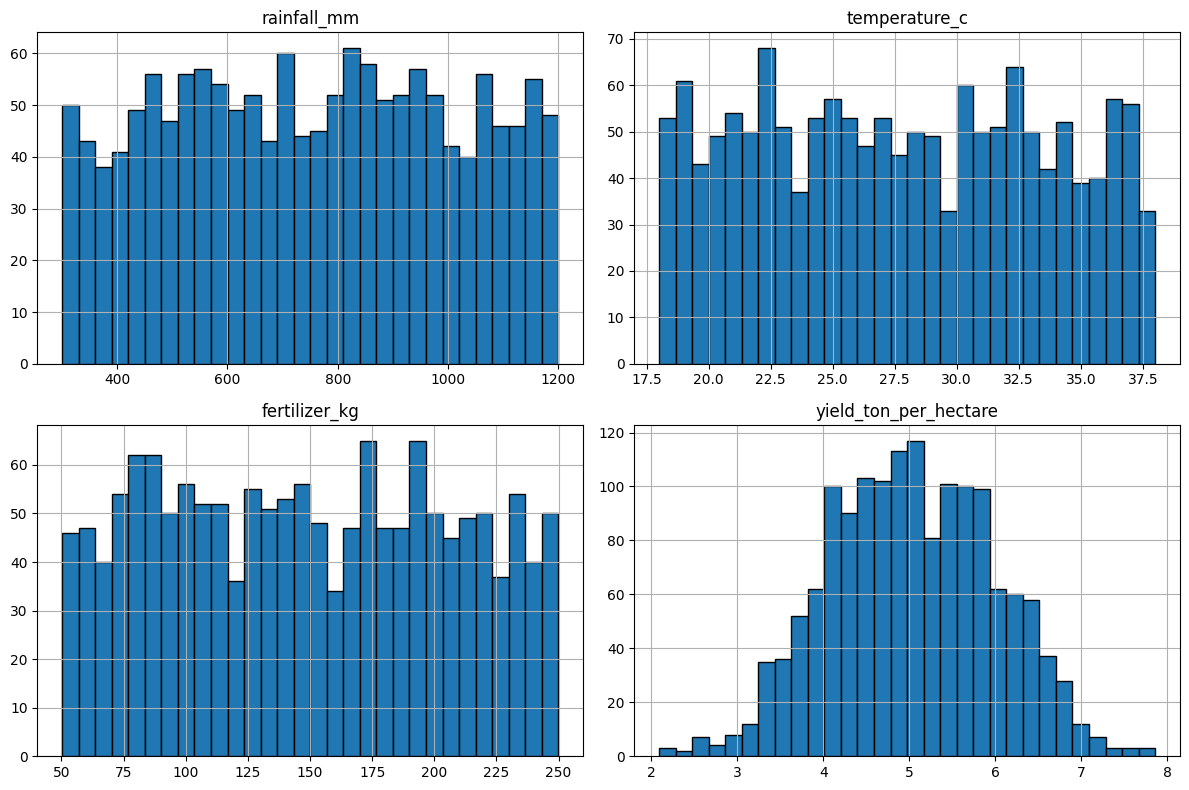

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
cols = ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'yield_ton_per_hectare']
for ax, col in zip(axes.flat, cols):
    df[col].hist(bins=30, ax=ax, edgecolor='black')
    ax.set_title(col)
plt.tight_layout()
plt.show()

Q5. Crop Type Analysis

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


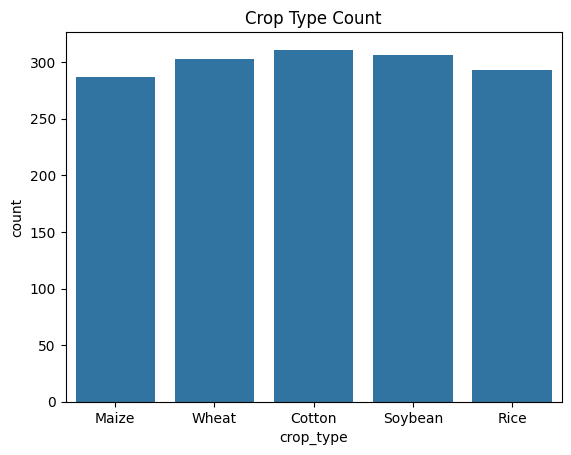

In [8]:
print(df['crop_type'].value_counts())
sns.countplot(data=df, x='crop_type')
plt.title('Crop Type Count')
plt.show()

Q6. Soil Type Analysis

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


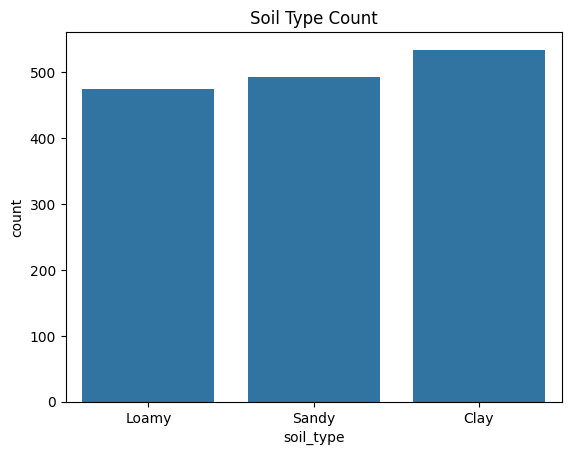

In [9]:
print(df['soil_type'].value_counts())
sns.countplot(data=df, x='soil_type')
plt.title('Soil Type Count')
plt.show()

Q7. Yield Distribution

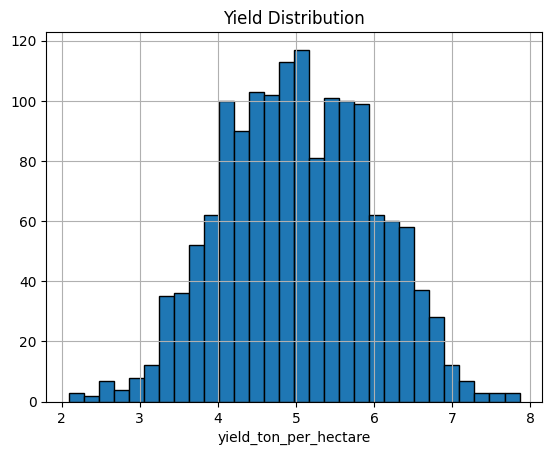

In [10]:
df['yield_ton_per_hectare'].hist(bins=30, edgecolor='black')
plt.title('Yield Distribution')
plt.xlabel('yield_ton_per_hectare')
plt.show()

Q8. Scatter Plot Analysis

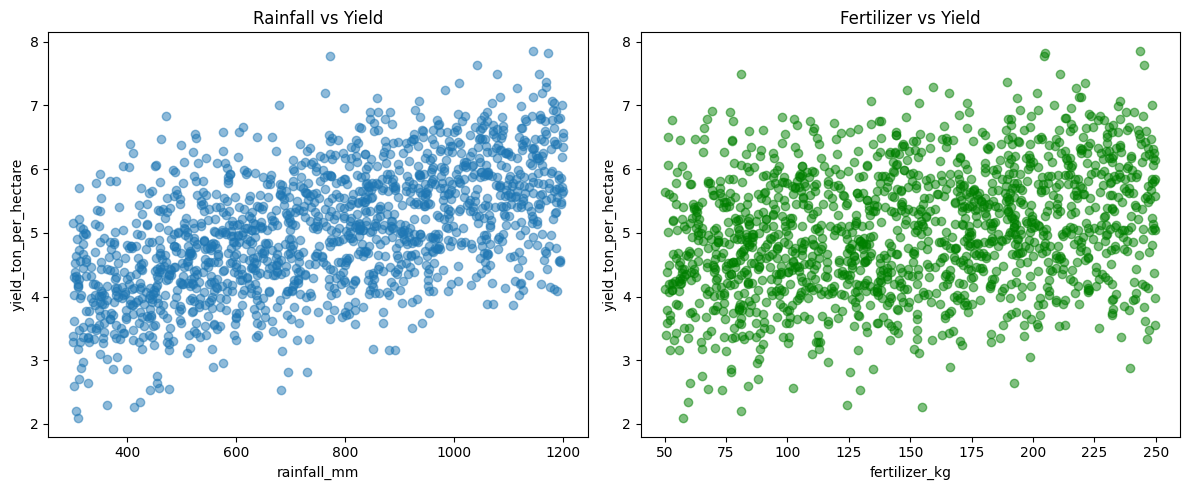

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(df['rainfall_mm'], df['yield_ton_per_hectare'], alpha=0.5)
axes[0].set_xlabel('rainfall_mm'); axes[0].set_ylabel('yield_ton_per_hectare')
axes[0].set_title('Rainfall vs Yield')

axes[1].scatter(df['fertilizer_kg'], df['yield_ton_per_hectare'], alpha=0.5, color='green')
axes[1].set_xlabel('fertilizer_kg'); axes[1].set_ylabel('yield_ton_per_hectare')
axes[1].set_title('Fertilizer vs Yield')
plt.tight_layout()
plt.show()

Q9. Correlation Analysis

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

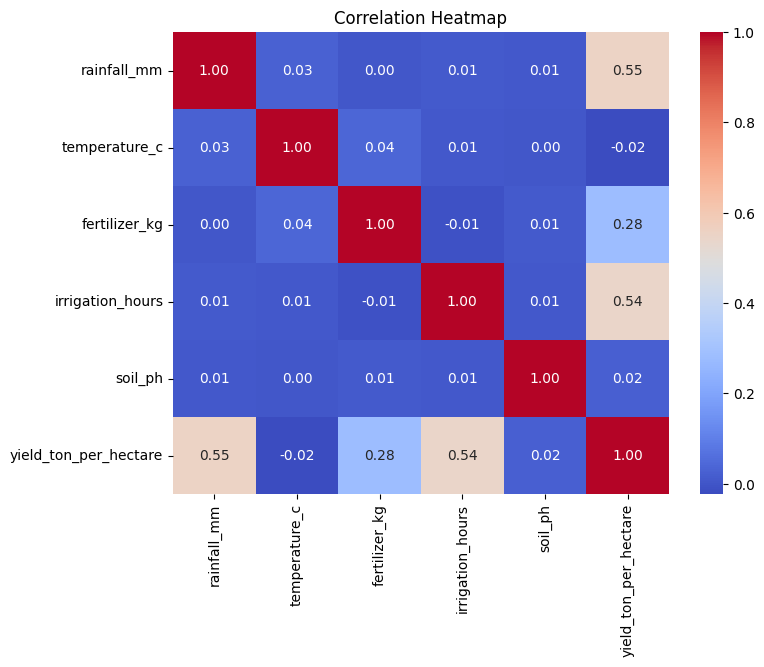

In [12]:
corr = df.corr(numeric_only=True)
print(corr)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Q10. Group-Based Analysis

In [13]:
print(df.groupby('crop_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False))
print(df.groupby('soil_type')['yield_ton_per_hectare'].mean().sort_values(ascending=False))

crop_type
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Maize      4.897143
Cotton     4.607299
Name: yield_ton_per_hectare, dtype: float64
soil_type
Loamy    5.366519
Clay     5.134326
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64


Q11. Feature Encoding

In [14]:
categorical_cols = ['crop_type', 'soil_type']
print("Categorical columns:", categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.head()

Categorical columns: ['crop_type', 'soil_type']


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,True,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,True,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,True,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,True,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,False,False,False,False,False,False


Q12. Feature Selection

In [15]:
X = df_encoded.drop('yield_ton_per_hectare', axis=1)
y = df_encoded['yield_ton_per_hectare']
print(X.columns.tolist())

['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type_Maize', 'crop_type_Rice', 'crop_type_Soybean', 'crop_type_Wheat', 'soil_type_Loamy', 'soil_type_Sandy']


Q13. Train-Test Split

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1200, 11)
X_test: (300, 11)
y_train: (1200,)
y_test: (300,)


Q14. Linear Regression Model

In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

coefs = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)
print(coefs)
print("Intercept:", model.intercept_)
print("Highest positive coefficient feature:", coefs.idxmax())

crop_type_Rice       0.863993
crop_type_Soybean    0.481719
crop_type_Wheat      0.348474
soil_type_Loamy      0.302974
crop_type_Maize      0.238931
irrigation_hours     0.198327
fertilizer_kg        0.004978
soil_ph              0.004901
rainfall_mm          0.002035
temperature_c       -0.009175
soil_type_Sandy     -0.490933
dtype: float64
Intercept: 1.587132027736121
Highest positive coefficient feature: crop_type_Rice
